In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import os
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

from daemon_analysis_tools.io.csv_handler import load_and_process_csv
from daemon_analysis_tools.io.yaml_handler import save_answers_to_yaml, load_answers_from_yaml
from daemon_analysis_tools.services.scoring import get_question_score, _get_question_type_lookup
from daemon_analysis_tools.io.yaml_base_handler import load_yaml


Load and process data:
- Group answers by publisher and journal, trying to uniform names written in slightly different ways.
- Store in a DataFrame

In [7]:
grouped_questions = load_answers_from_yaml('../../data/processed/all_answers')

No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

In [8]:
tags_lookup = {"language understanding" : "Comprehension",
               "Language understanding" : "Comprehension",
               "difficulty in matching information and question" : "Comprehension",
               "Difficulty in matching information and question" : "Comprehension",
               "Selected answer is better interpretation of RDP." : "Comprehension",
               "Text missing and language understanding" : "Comprehension",
               "Text missing and Language understanding" : "Comprehension",
               "Text missing and  language understanding" : "Comprehension",
               "Text not found" : "Missed text",
               "Missed text." : "Missed text",
               "Text missing" : "Missed text",
               "Formatting inconsistent" : "Formatting",
               "Same answer but different wording." : "Formatting",
               "Inconsistent formatting." : "Formatting",
               None : "Consistent"}

inconsistencies_per_publisher = {}

for publisher, journals in grouped_questions.items():
    n_question = 0
    inconsistencies = {"Consistent": 0}

    for journal, data in journals.items():
        print(f"Processing {publisher} - {journal}...")
        for question, answer in data.items():
            n_question += 1

            if not answer.has_multiple_answers():
                continue

            if answer.has_discrepancies():
                discrepancy_reason = answer.discrepancy_reason

                if discrepancy_reason in tags_lookup:
                    discrepancy_reason = tags_lookup[discrepancy_reason] 

                if not discrepancy_reason in inconsistencies:
                    inconsistencies[discrepancy_reason] = 0

                inconsistencies[discrepancy_reason] += 1
            else:
                inconsistencies["Consistent"] += 1

    print(publisher, inconsistencies)
    inconsistencies_per_publisher[publisher] = inconsistencies

Processing ACS - acs_energy_letters...
Processing ACS - jacs_au...
Processing ACS - journal_of_medicinal_chemistry...
Processing ACS - accounts_of_chemical_research...
Processing ACS - acs_omega...
Processing ACS - inorganic_chemistry...
Processing ACS - applied_materials_and_interfaces...
Processing ACS - the_journal_of_organic_chemistry...
Processing ACS - the_journal_of_physical_chemistry_c...
Processing ACS - chemrxiv...
Processing ACS - accounts_of_materials_research...
Processing ACS - environmental_science_and_technology...
Processing ACS - jacs...
Processing ACS - journal_of_the_american_society_for_mass_spectrometry...
Processing ACS - acs_es_and_t_engineering...
ACS {'Consistent': 147, 'Missed text': 59, 'Formatting': 9, 'Comprehension': 11}
Processing AIP - physics_of_plasmas...
Processing AIP - review_of_scientific_instruments...
Processing AIP - low_temperature_physics...
Processing AIP - journal_of_applied_physics...
Processing AIP - applied_physics_reviews...
Processing 

Get a `dict` labeled by publisher names of `dict`s labeled by journal names of `dict`s of `Question` instances. The `.answer` attribute contains the answers given by the respondents and the explanations text to motivate it.

[156  59  11] ['Consistent', 'Missed text', 'Comprehension']
[215  16   7] ['Consistent', 'Comprehension', 'Missed text']
[205   4] ['Consistent', 'Comprehension']
[90 18  6] ['Consistent', 'Comprehension', 'Missed text']
[102  12  19] ['Consistent', 'Missed text', 'Comprehension']
[63 21 35] ['Consistent', 'Comprehension', 'Missed text']
[240  30] ['Consistent', 'Missed text']
[139  14] ['Consistent', 'Comprehension']
[141 114  30] ['Consistent', 'Comprehension', 'Missed text']
[85 10] ['Consistent', 'Comprehension']
[115  29  27] ['Consistent', 'Comprehension', 'Missed text']
[106  24  41] ['Consistent', 'Comprehension', 'Missed text']
[130  57   1] ['Consistent', 'Missed text', 'Rejected insider information']
[257  28] ['Consistent', 'Comprehension']
[167  75  43] ['Consistent', 'Missed text', 'Comprehension']
[16  1  2] ['Consistent', 'Comprehension', 'Missed text']
[10  8  1] ['Consistent', 'Missed text', 'Comprehension']


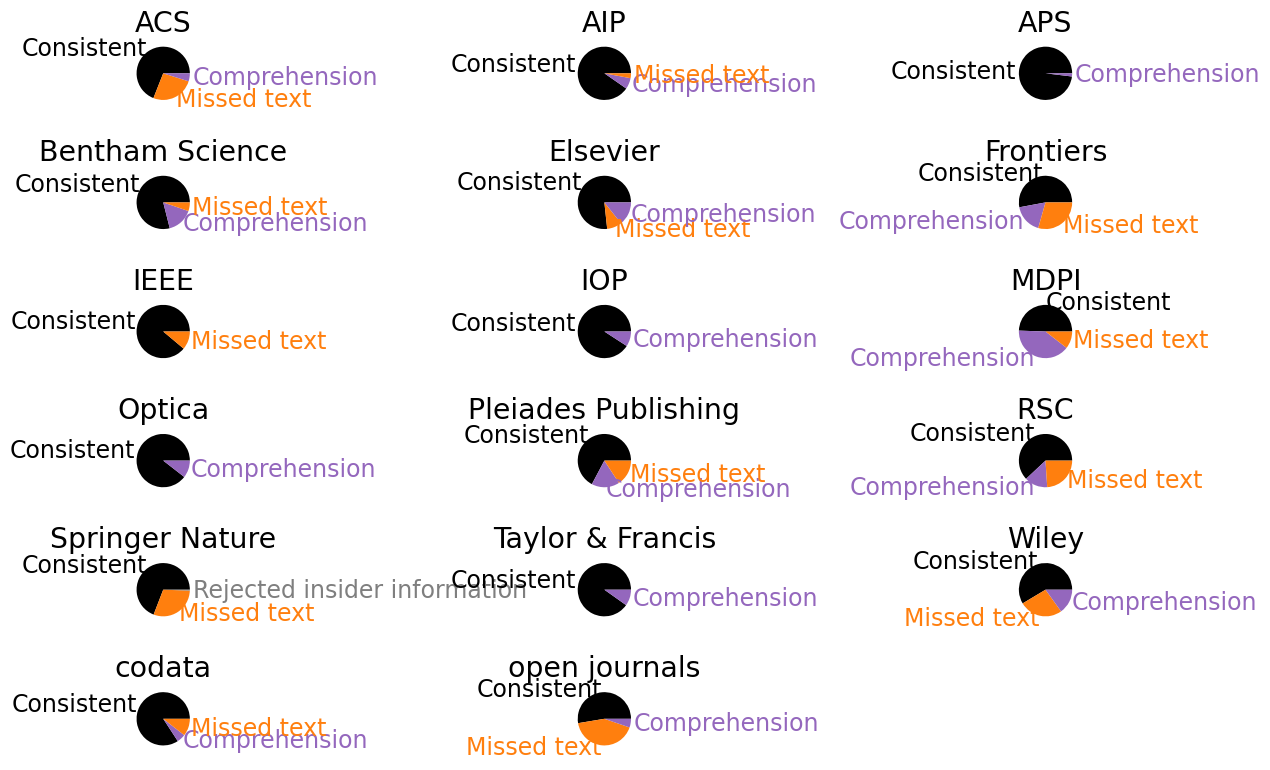

In [9]:
import numpy as np
from copy import deepcopy
from matplotlib import pyplot as plt

color_dict = {"Consistent" : "k",
          "Missed text" : "C1",
          "Comprehension" : "C4",
          "Rejected insider information" : "C7",

}

fig = plt.figure(figsize=(12, 8))
inconsistency_type_counts = {"Consistent": 0, "Missed text": 0, "Comprehension": 0}

for ind, (publisher, data_0) in enumerate(inconsistencies_per_publisher.items()):
    data = deepcopy(data_0)

    if "Formatting" in data:
        data["Consistent"] += data["Formatting"]
        data.pop("Formatting", None)

    y = np.array(list(data.values()))
    labels = list(data.keys())

    print(y, labels)

    w = 3
    h = int(np.ceil(len(inconsistencies_per_publisher)/w))

    colors = []
    for l in labels:
        colors.append(color_dict[l])

    plt.subplot(h, w, ind+1)
    plt.title(publisher)
    _, texts = plt.pie(y, labels=labels, colors=colors)

    for text, color in zip(texts, colors):
        text.set_color(color)
    
    for key in inconsistency_type_counts.keys():
        if key in data:
            inconsistency_type_counts[key] += data[key]

plt.tight_layout()
fig.savefig("../../data/processed/inconsistencies.pdf")

Total inconsistencies: 2979
Consistent: 2237 (75.09%)
Missed text: 389 (13.06%)
Comprehension: 353 (11.85%)


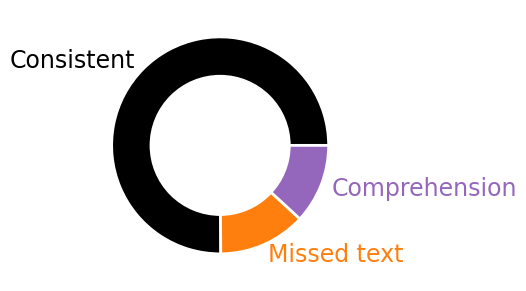

In [10]:
total = sum(inconsistency_type_counts.values())
print("Total inconsistencies:", total)
for key, value in inconsistency_type_counts.items():
    print(f"{key}: {value} ({value/total*100:.2f}%)")

#pie chart with hole
import seaborn as sns 
import textwrap
fig = plt.figure(figsize=(3.5, 9))
counts = np.array(list(inconsistency_type_counts.values()))
labels = list(inconsistency_type_counts.keys())
colors = [color_dict[label] for label in labels]
wedges, texts = plt.pie(counts,
                        labels=labels,
                        colors=colors,
                        wedgeprops = {"edgecolor" : "white", 
                        'linewidth': 2, 
                        'antialiased': True},
                        #autopct='%1.1f%%',
                        )

### Add a hole in the pie  
hole = plt.Circle((0, 0), 0.65, facecolor='white')
plt.gcf().gca().add_artist(hole)

for text, color in zip(texts, colors):
    text.set_color(color)

plt.savefig("../../data/processed/inconsistencies_summarized.pdf", bbox_inches='tight')

In [11]:
# the following code computes inconsistency rate per question across all publishers/journals to identify the most inconsistently answered questions

inconsistencies_by_question = {}

from collections import defaultdict
answers_all = defaultdict(list)

for publisher, journals in grouped_questions.items():
    for journal, data in journals.items():
        for question, answer in data.items():
            if not answer.has_multiple_answers():
                continue

            q_bucket = inconsistencies_by_question.setdefault(question, {"Consistent": 0, "Total": 0})
            q_bucket["Total"] += 1

            if answer.has_discrepancies():
                reason = answer.discrepancy_reason
                if reason in tags_lookup:
                    reason = tags_lookup[reason]
                if reason not in q_bucket:
                    q_bucket[reason] = 0
             
                if reason != "Formatting":
                    q_bucket[reason] = q_bucket.get(reason, 0) + 1
                    answers_all[question].append(set([el.text for el in answer.answers]))
                else:
                    q_bucket["Consistent"] += 1
            else:
                q_bucket["Consistent"] += 1

# Compute inconsistency rate and sort
question_stats = []
for question, counts in inconsistencies_by_question.items():
    total = counts["Total"]
    inconsistent_count = total - counts["Consistent"]
    inconsistency_rate = inconsistent_count / total if total > 0 else 0
    question_stats.append((question, counts, inconsistency_rate))

# Sort by highest inconsistency rate
question_stats.sort(key=lambda x: x[2], reverse=True)

# Display results
for question, counts, rate in question_stats:
    print(f"{question} | Inconsistency Rate: {rate:.1%} | Counts: {counts}")

data_sharing_method | Inconsistency Rate: 62.1% | Counts: {'Consistent': 61, 'Total': 161, 'Missed text': 56, 'Comprehension': 44}
data_timing | Inconsistency Rate: 44.1% | Counts: {'Consistent': 90, 'Total': 161, 'Missed text': 31, 'Comprehension': 40}
data_required | Inconsistency Rate: 42.5% | Counts: {'Consistent': 65, 'Total': 113, 'Formatting': 0, 'Missed text': 31, 'Comprehension': 17}
data_recommended | Inconsistency Rate: 40.0% | Counts: {'Consistent': 78, 'Total': 130, 'Formatting': 0, 'Missed text': 39, 'Comprehension': 13}
data_sharing | Inconsistency Rate: 36.6% | Counts: {'Consistent': 102, 'Total': 161, 'Missed text': 17, 'Comprehension': 42}
data_citability | Inconsistency Rate: 32.3% | Counts: {'Consistent': 109, 'Total': 161, 'Missed text': 34, 'Comprehension': 18}
code_required | Inconsistency Rate: 32.3% | Counts: {'Consistent': 109, 'Total': 161, 'Missed text': 23, 'Comprehension': 29}
data_fair | Inconsistency Rate: 30.4% | Counts: {'Consistent': 112, 'Total': 161

In [12]:
counter = 0
for el in answers_all['data_sharing_method']:
    if 'Multiple data sharing methods equally recommended in RDP.' in el:
        counter += 1

print(f"Count of 'Multiple data sharing methods equally recommended in RDP.': {counter}")

Count of 'Multiple data sharing methods equally recommended in RDP.': 76


In [13]:
# the following code computes average inconsistency scores per publisher
from daemon_analysis_tools.io.csv_handler import _load_csv

csv_read = _load_csv("../../data/metadata/journal_selection.csv")

impact_factor_dict = {}
for journal, impact_factor in zip(csv_read["title"], csv_read["citations_avg"]):
    impact_factor_dict[journal.lower().replace(" ", "_")] = impact_factor

print(impact_factor_dict)
#print(csv_read["title"], csv_read["citations_avg"], csv_read["citations_median"])
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


data_dir = os.path.join("..", "..", "src/daemon_analysis_tools/metadata")

multiple_choice_scores = load_yaml(
    os.path.join(data_dir, "question_metadata_score.yaml")
)
question_type = load_yaml(os.path.join(data_dir, "question_type.yaml"))
question_number_lookup = _get_question_type_lookup(multiple_choice_scores)


question_type = load_yaml(os.path.join(data_dir, "question_type.yaml"))
question_number_lookup = _get_question_type_lookup(multiple_choice_scores)

publisher_scores = {}  # stores results per publisher

for publisher, publisher_results in processed_data.items():
    score_dict = defaultdict(int)
    n_journals = 0

    for journal, journal_results in publisher_results.items():
        n_journals += 1

        for question, answer in journal_results.items():
            score_dict[question] += get_question_score(
                question,
                answer,
                multiple_choice_scores,
                question_type,
                question_number_lookup,
            )

    # normalize by number of journals for this publisher
    for question in score_dict:
        score_dict[question] /= n_journals

    # sort per publisher
    sorted_dict = dict(
        sorted(score_dict.items(), key=lambda item: item[1], reverse=True)
    )

    publisher_scores[publisher] = sorted_dict


[info] CSV loaded ← ../../data/metadata/journal_selection.csv
{'escience': 47.79047619047619, 'applied_catalysis_b_environmental': 39.88368891947695, 'energy_storage_materials': 28.907997169143663, 'nano_energy': 29.69001610305958, 'food_hydrocolloids': 27.77777777777778, 'advanced_powder_materials': 47.19642857142857, 'joule': 43.5125348189415, 'ssrn_electronic_journal': 0.1664711127798376, 'materials_today_proceedings': 5.190393518518518, 'chemical_engineering_journal': 21.943821038152464, 'journal_of_alloys_and_compounds': 10.656837506825806, 'ceramics_international': 8.925697674418604, 'bioactive_materials': 22.83080808080808, 'composites_part_a_applied_science_and_manufacturing': 14.213085764809902, 'materials_science_and_engineering_a': 11.167504630854724, 'superlattices_and_microstructures': 9.12735849056604, 'materials_today_bio': 8.105442176870747, 'accounts_of_chemical_research': 29.07106598984772, 'acs_energy_letters': 27.080745341614907, 'journal_of_the_american_chemical_so

Pearson r: -0.7345874561828243 p: 0.0007838269450010816


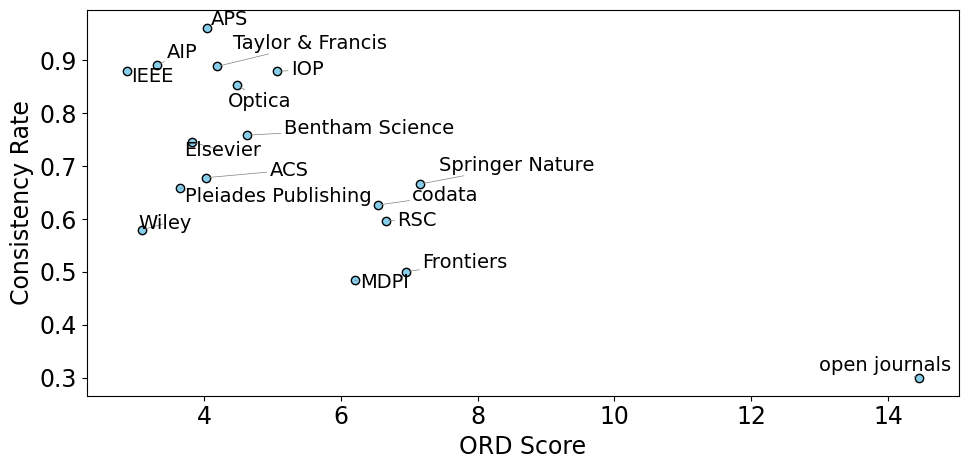

In [14]:
for publisher_name in inconsistencies_per_publisher:
    inconsistencies_per_publisher[publisher_name]["ORD_score"] = sum(publisher_scores[publisher_name].values())
    inconsistencies_per_publisher[publisher_name]["total"] = sum(inconsistencies_per_publisher[publisher_name].values())
    inconsistencies_per_publisher[publisher_name]["consistency_rate"] = (inconsistencies_per_publisher[publisher_name]["Consistent"] + inconsistencies_per_publisher[publisher_name].get("Formatting", 0)) / inconsistencies_per_publisher[publisher_name]["total"]

#plot consistency rate vs ORD score
fig = plt.figure(figsize=(10, 5))
from adjustText import adjust_text
x = [inconsistencies_per_publisher[key]["ORD_score"] for key in inconsistencies_per_publisher]
y = [inconsistencies_per_publisher[key]["consistency_rate"] for key in inconsistencies_per_publisher]
tags = [key for key in inconsistencies_per_publisher]
plt.scatter(x, y, color='skyblue', edgecolor='black')
texts = [plt.text(x[i], y[i], tags[i], fontsize=14) for i in range(len(tags))]
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.xlabel("ORD Score")
plt.ylabel("Consistency Rate")
plt.tight_layout()
fig.savefig("../../data/processed/consistency_vs_ord_score.pdf")
from scipy.stats import pearsonr, spearmanr

# Pearson correlation (assumes linear relationship)
r_pearson, p_pearson = pearsonr(x, y)

print("Pearson r:", r_pearson, "p:", p_pearson)
